In [1]:
pip install polars matplotlib typing_extensions==4.11.0 great_tables numpy seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import polars as pl
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from great_tables import GT, style, loc
from mts_study import *

# Setup

In [3]:
# plot setup
plt.rcParams['figure.figsize'] = [14,8]

color_map = {
    "libfabric": "blue",
    "native": "orange",
    "ucx": "green",
    "libfabric-fix": "red",
}

sns.set_theme(style="whitegrid")

data_dir = "../data/mts-study"

# Transfers

## Device to Device Inter-Host

In [4]:
config = {"libraries":[Library.libfabric, Library.native], "tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}
data, perf, _ = load_data(f"{data_dir}/d2d-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device to Device Inter-Host transfers

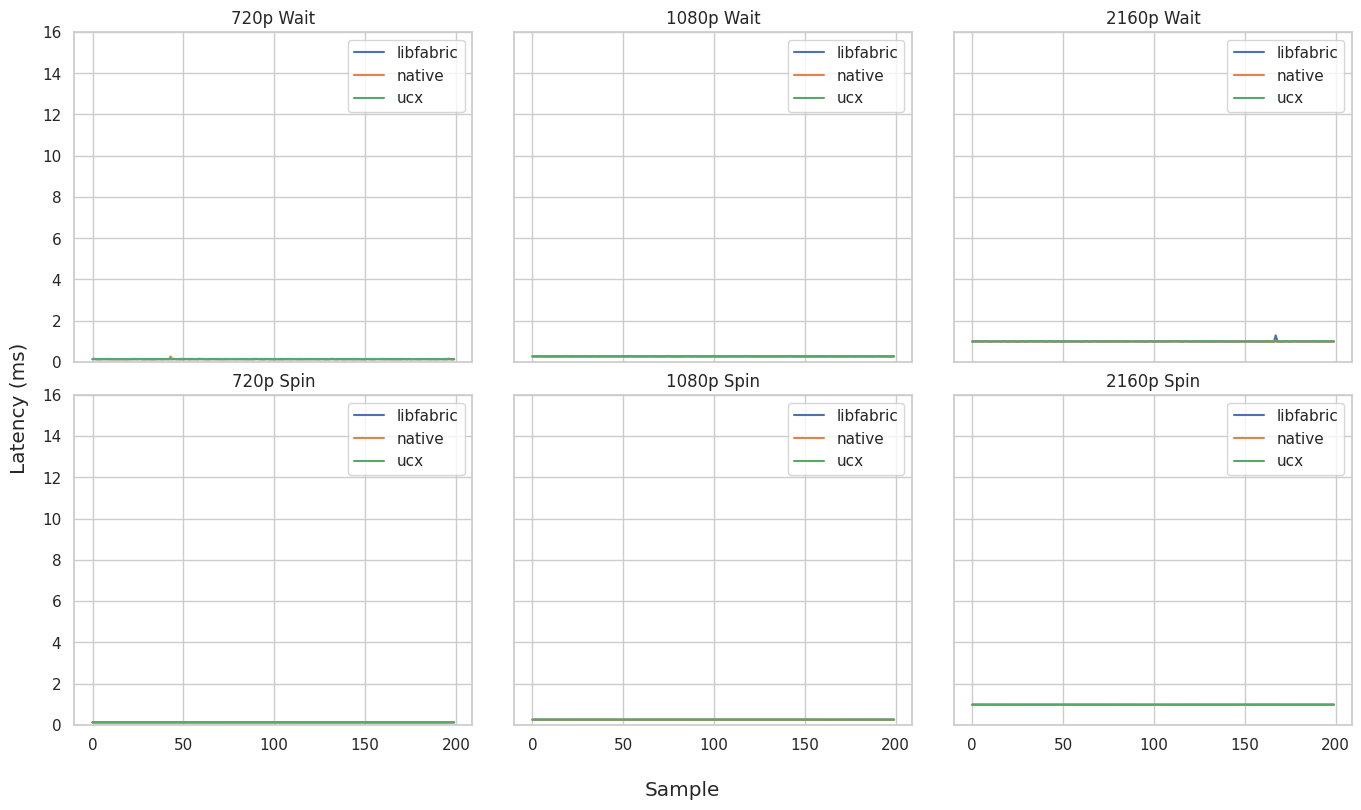

In [5]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in [Library.libfabric,  Library.native]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.verbs, TransferMode.reflect)]/2/1e6, label=f"{library.value}")
        axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.reflect)]/2/1e6, label=f"ucx")
        axs[j][i].legend()

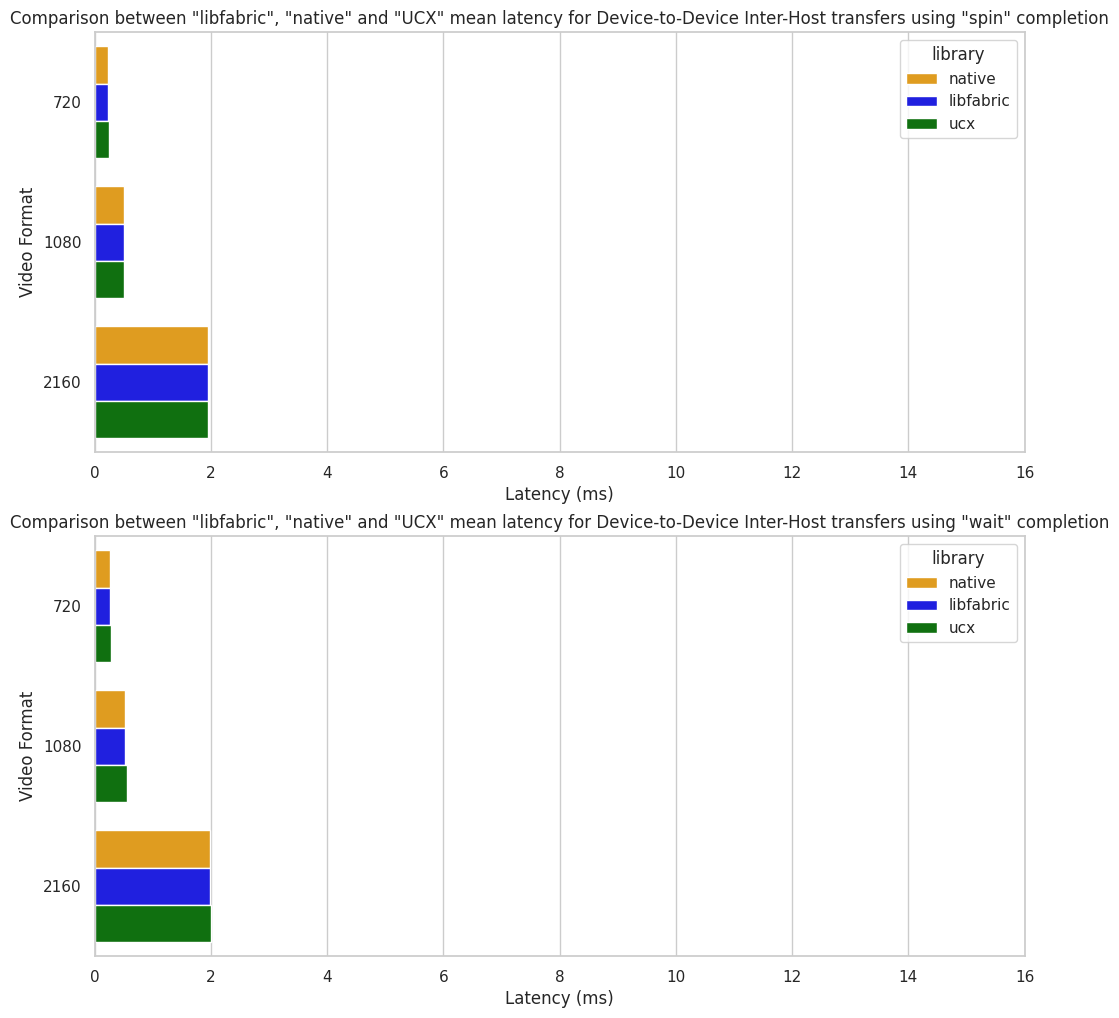

In [6]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps=[Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "native" and "UCX" mean latency for Device-to-Device Inter-Host transfers using "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [7]:
data_columns = ["format", "library", "completion"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["format","completion"])
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["format","completion"])
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["format","completion"])

In [8]:
table= GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ libfabric ┆ Spin       ┆ 0.2358   ┆ 0.2378  ┆ 0.0008  ┆ 0.0298    │
│ 720    ┆ native    ┆ Spin       ┆ 0.2305   ┆ 0.232   ┆ 0.0005  ┆ 0.0292    │
│ 720    ┆ ucx       ┆ Spin       ┆ 0.2408   ┆ 0.2443  ┆ 0.0007  ┆ 0.0304    │
│ 720    ┆ libfabric ┆ Wait       ┆ 0.2605   ┆ 0.3094  ┆ 0.009   ┆ 0.0174    │
│ 720    ┆ native    ┆ Wait       ┆ 0.2611   ┆ 0.527   ┆ 0.0203  ┆ 0.0045    │
│ 720    ┆ ucx       ┆ Wait       ┆ 0.2807   ┆ 0.2979  ┆ 0.0057  ┆ 0.0067    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72136d088d40>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72137c1ee0f0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1280x720 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72137c11bc80>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='nor

In [9]:
table= GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1920x1080 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ libfabric ┆ Spin       ┆ 0.5016   ┆ 0.5041  ┆ 0.001   ┆ 0.0618    │
│ 1080   ┆ native    ┆ Spin       ┆ 0.4964   ┆ 0.4988  ┆ 0.0008  ┆ 0.0612    │
│ 1080   ┆ ucx       ┆ Spin       ┆ 0.5063   ┆ 0.5109  ┆ 0.0008  ┆ 0.0623    │
│ 1080   ┆ libfabric ┆ Wait       ┆ 0.5267   ┆ 0.5754  ┆ 0.0091  ┆ 0.0176    │
│ 1080   ┆ native    ┆ Wait       ┆ 0.5256   ┆ 0.5749  ┆ 0.0087  ┆ 0.0042    │
│ 1080   ┆ ucx       ┆ Wait       ┆ 0.5483   ┆ 0.5659  ┆ 0.0064  ┆ 0.0067    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7213e418dbb0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72136e95db20>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1920x1080 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7213e46e0e90>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='no

In [10]:
table= GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
     .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (6, 7)
┌────────┬───────────┬────────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ libfabric ┆ Spin       ┆ 1.952    ┆ 1.9562  ┆ 0.0023  ┆ 0.2358    │
│ 2160   ┆ native    ┆ Spin       ┆ 1.9466   ┆ 1.9506  ┆ 0.0022  ┆ 0.2352    │
│ 2160   ┆ ucx       ┆ Spin       ┆ 1.9545   ┆ 1.9584  ┆ 0.0024  ┆ 0.2362    │
│ 2160   ┆ libfabric ┆ Wait       ┆ 1.9796   ┆ 2.578   ┆ 0.0433  ┆ 0.0176    │
│ 2160   ┆ native    ┆ Wait       ┆ 1.977    ┆ 2.0308  ┆ 0.0104  ┆ 0.0043    │
│ 2160   ┆ ucx       ┆ Wait       ┆ 1.9986   ┆ 2.019   ┆ 0.008   ┆ 0.0067    │
└────────┴───────────┴────────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72137c104980>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72136d0c1eb0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 3840x2160 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72136d0c2540>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='no

## Device to Host 2 Host to Device Inter-host

In [11]:
config = {"libraries":[Library.libfabric, Library.native],"tests": [Test.mxl_fabrics, Test.ucx], "movements": [Movement.d2d, Movement.dh2hd], "transports":[Transport.verbs], "tx_modes": [TransferMode.reflect], "completions": [Completion.wait, Completion.spin]}

# load data
data, perf, pcie = load_data(f"{data_dir}/dh2hd-interhost", timers_loader, **config)

### Comparison libfabric vs native for Device-to-Host-to-Host-to-Device transfers

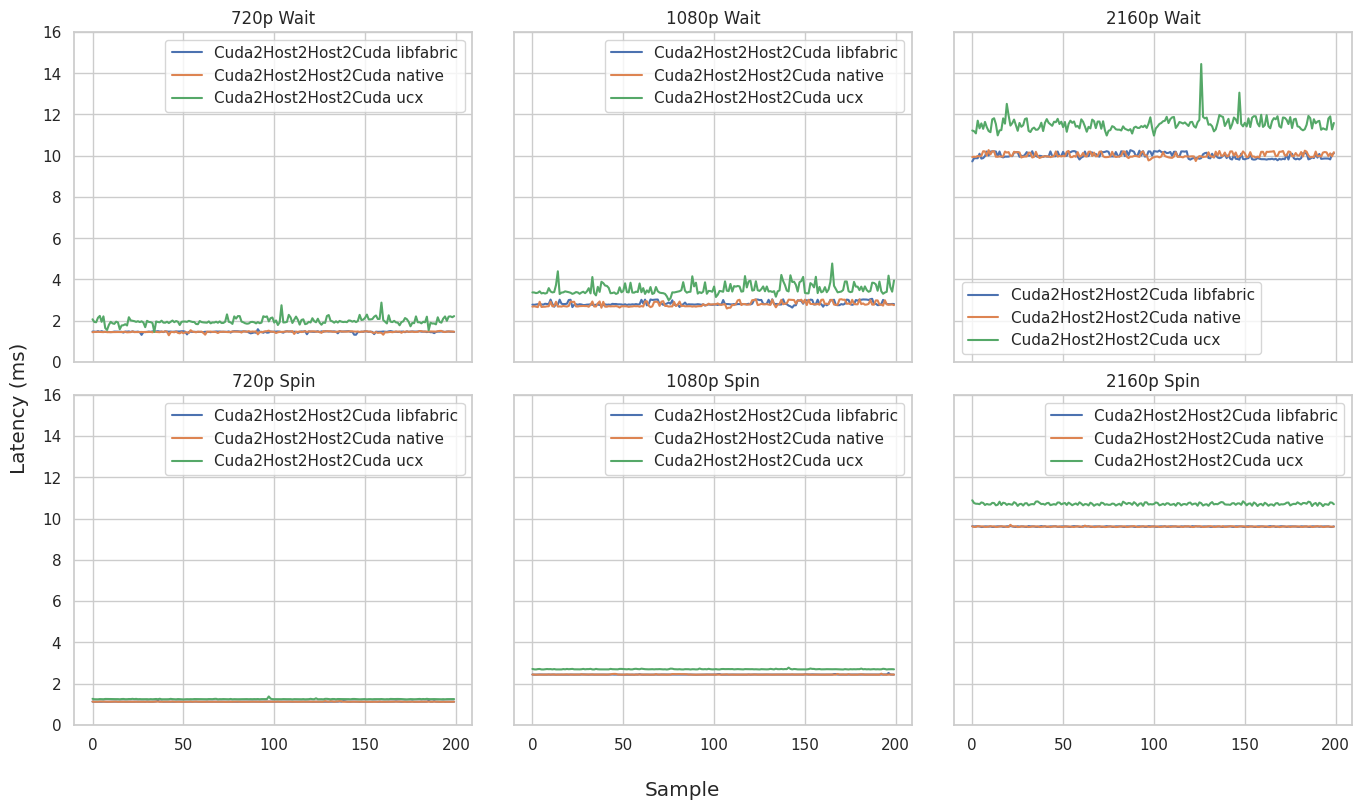

In [12]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for library in config["libraries"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
        axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.dh2hd, Transport.none, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} ucx")
        axs[j][i].legend()

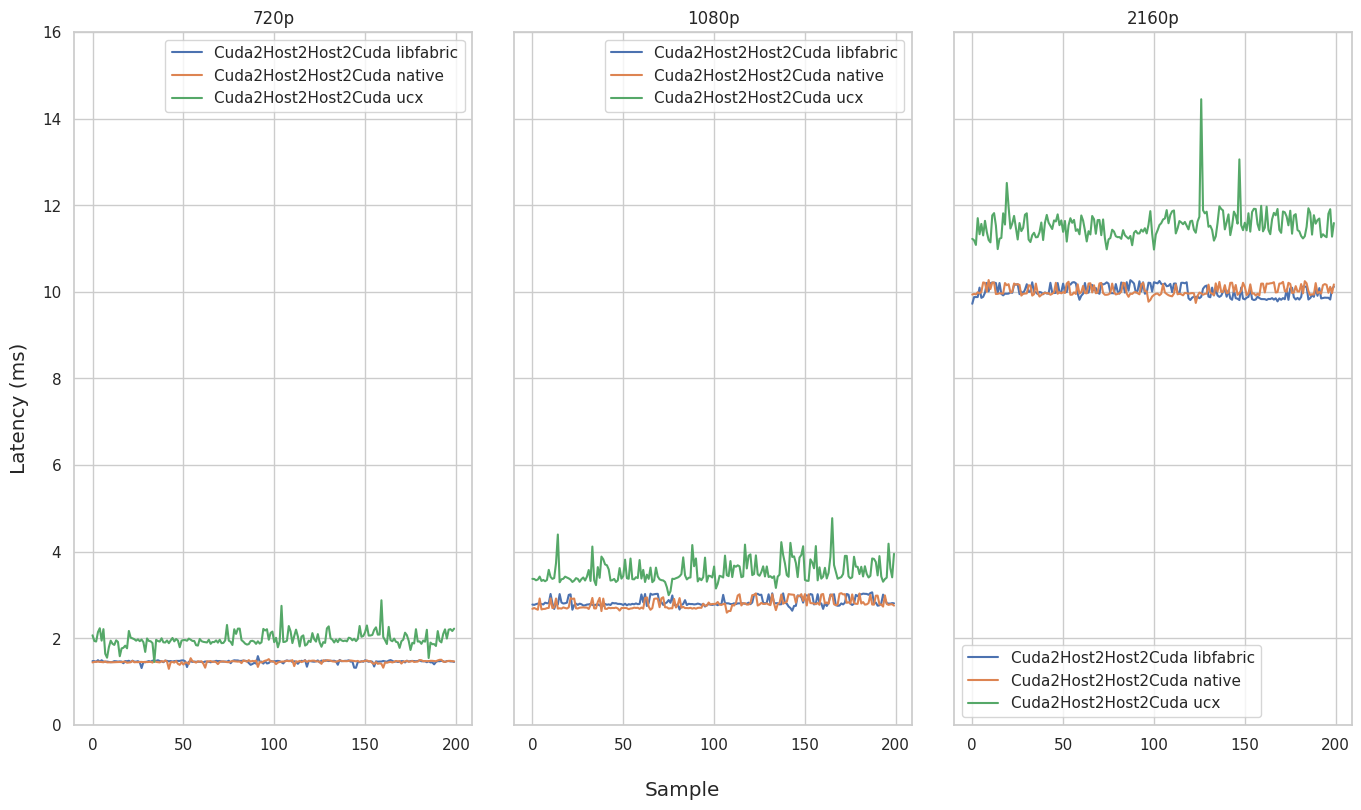

In [13]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=1,ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(ymin, ymax)
    for library in config["libraries"]:
        axs[i].plot(data[TestConfiguration(library, format, Completion.wait, Test.mxl_fabrics, Movement.dh2hd, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} {library.value}")
    axs[i].plot(data[TestConfiguration(Library.ucx, format, Completion.wait, Test.ucx, Movement.dh2hd, Transport.none, TransferMode.reflect)]/1e6, label=f"{Movement.dh2hd.value} ucx")
    axs[i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using libfabric

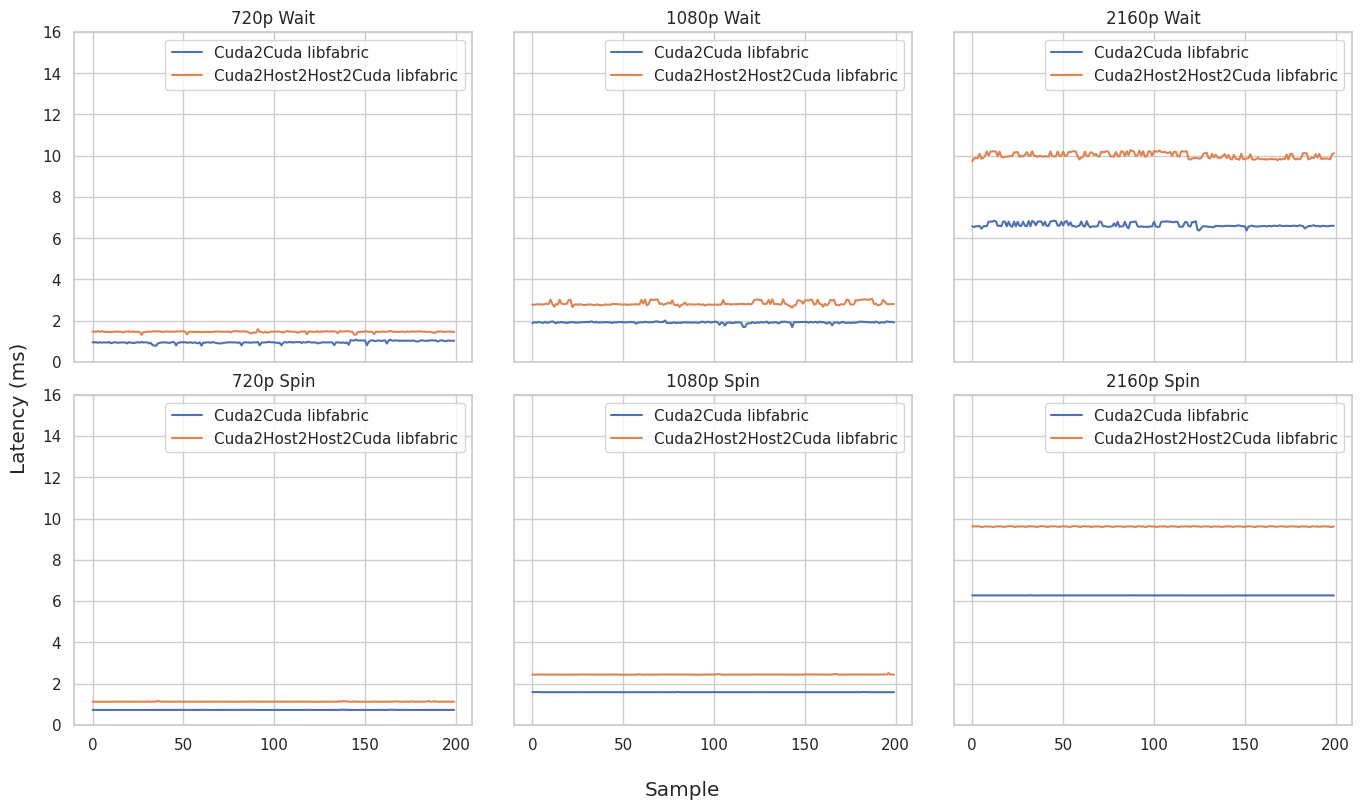

In [14]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.libfabric

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.value} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using native

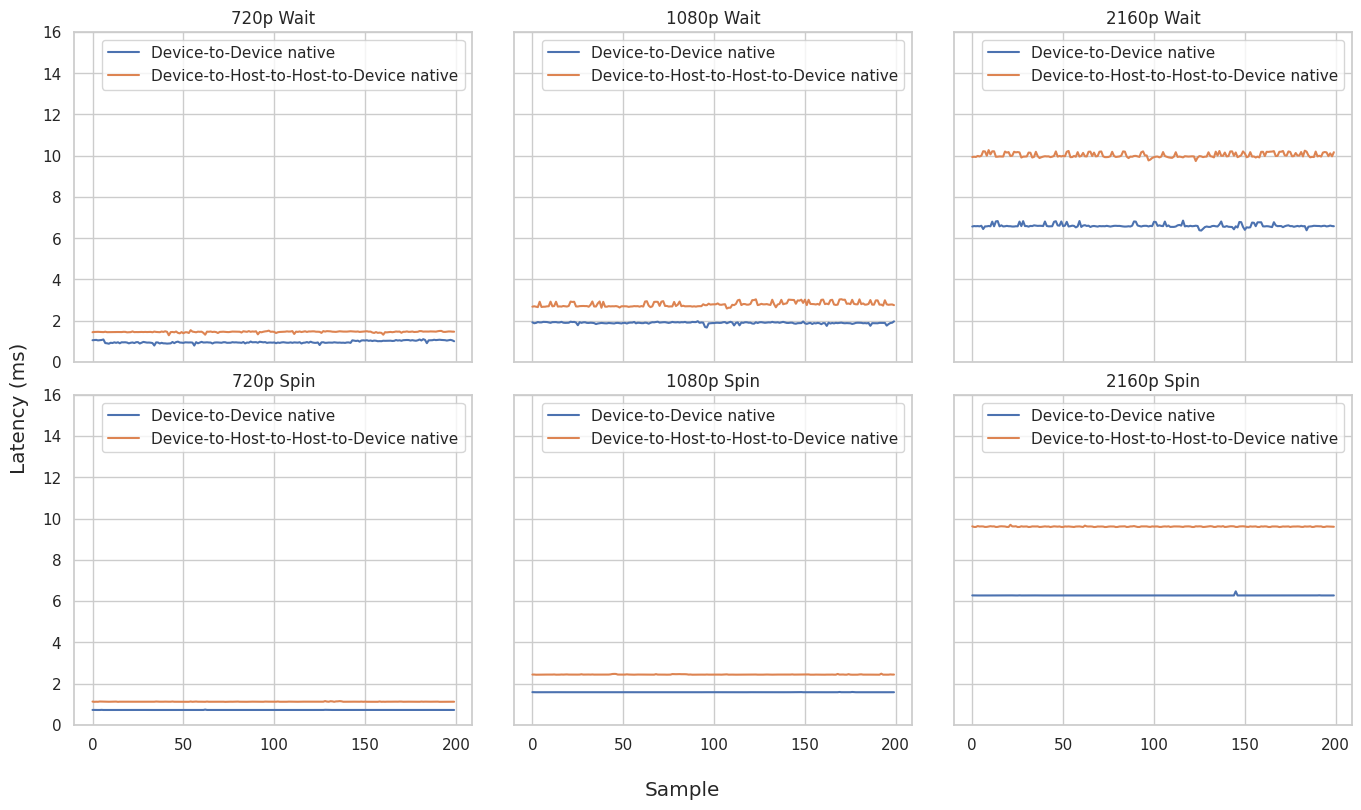

In [15]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

library = Library.native

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(library, format, comp, Test.mxl_fabrics, movement, Transport.verbs, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} {library.value}")
            axs[j][i].legend()

### Comparison Device-to-Device vs Device-to-Host-to-Host-to-Device using UCX

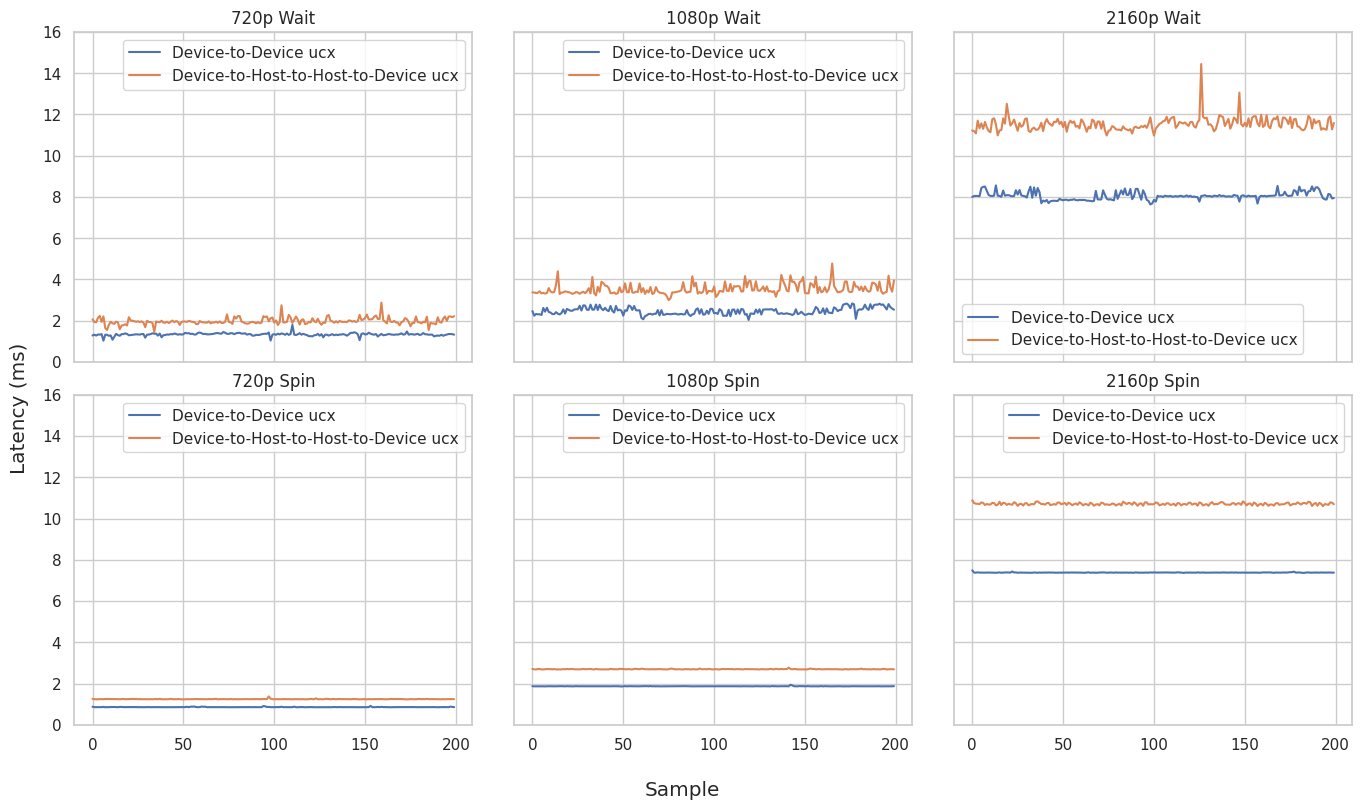

In [16]:
ymin, ymax = 0, 16
fig, axs = plt.subplots(nrows=len(config["completions"]),ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for j, comp in enumerate(config["completions"]):
        axs[j][i].set_title(f"{format.value}p {comp.value}")
        axs[j][i].set_ylim(ymin, ymax)
        for movement in config["movements"]:
            axs[j][i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, movement, Transport.none, TransferMode.reflect)]/1e6, label=f"{movement.to_study_name()} ucx")
            axs[j][i].legend()


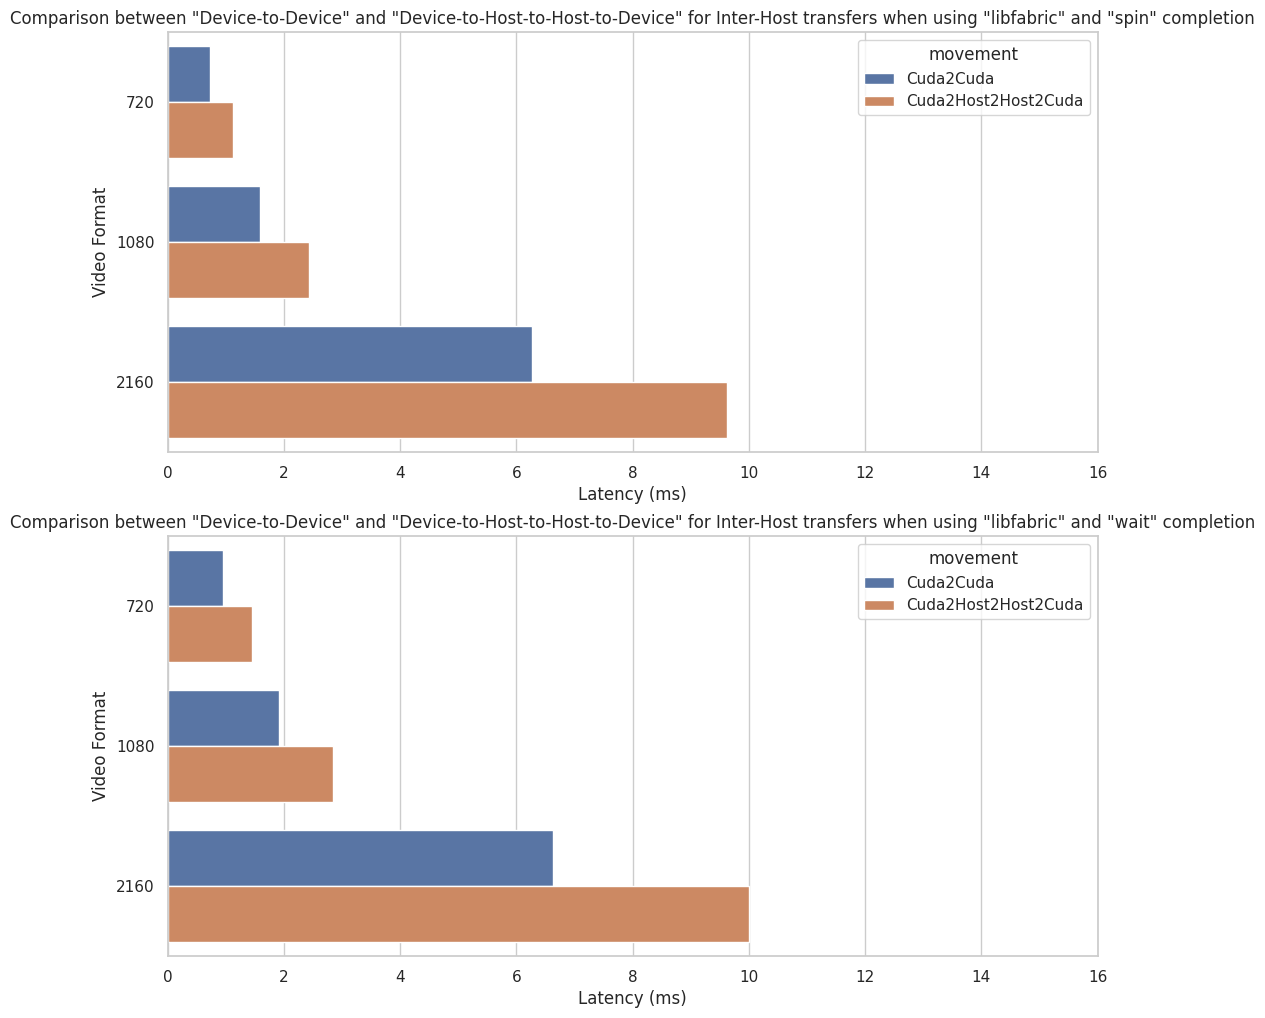

In [17]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "libfabric" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "libfabric"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

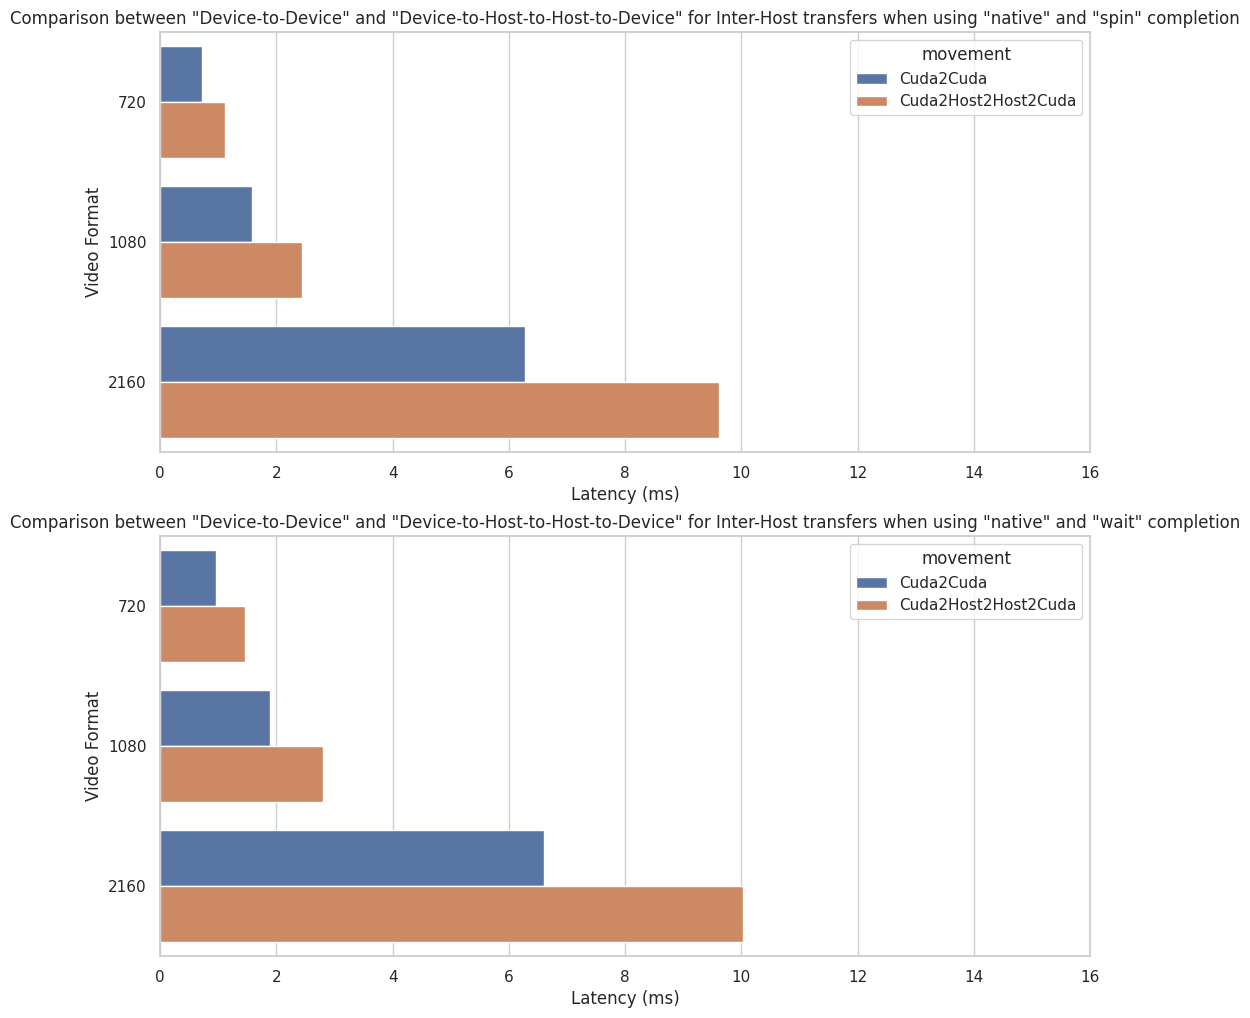

In [18]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "native" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "native"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

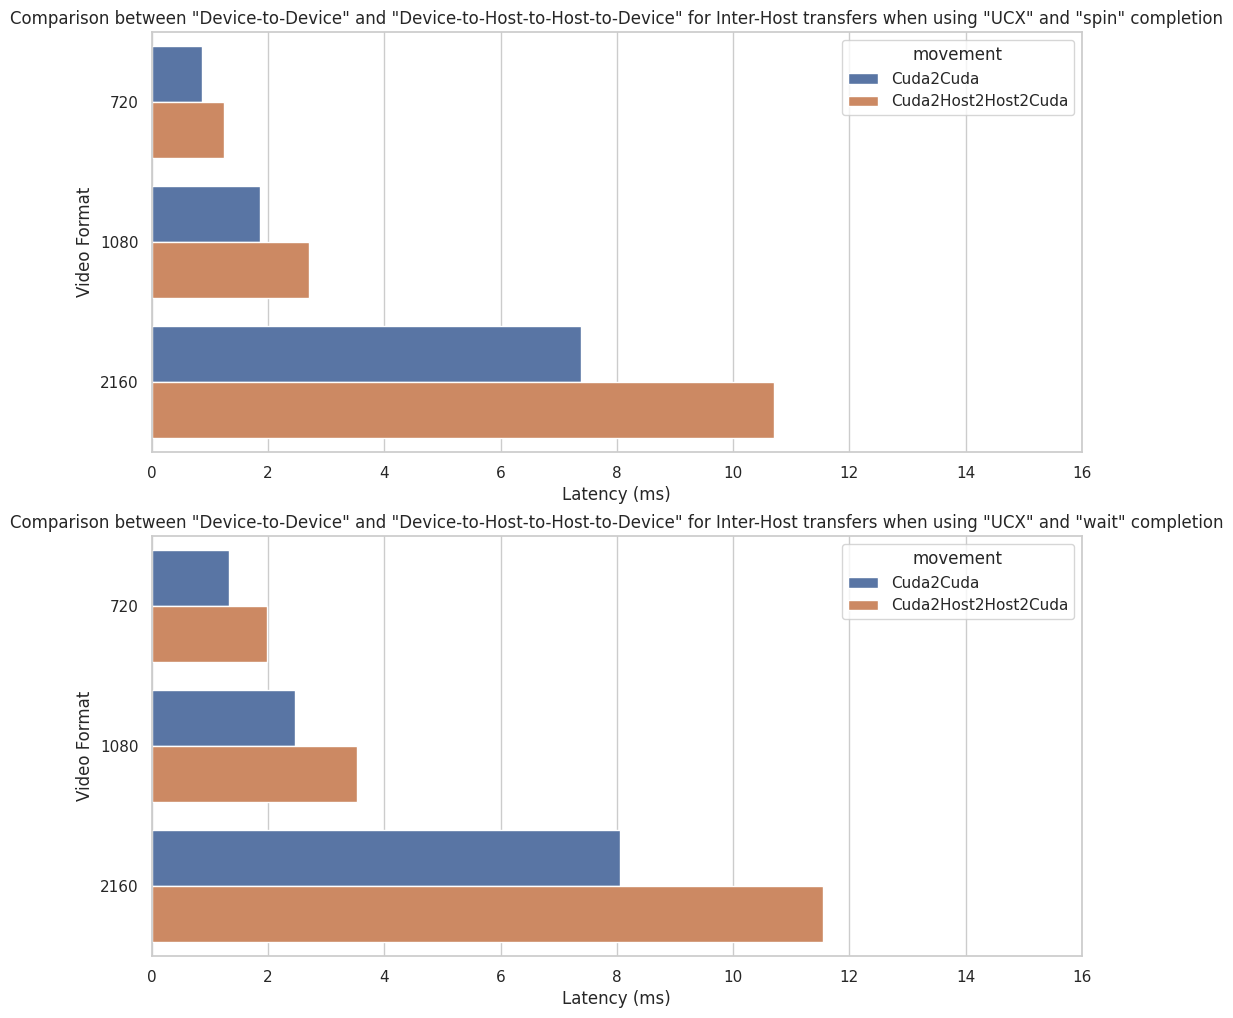

In [19]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])
# only keep used movements
data_df = data_df.with_columns(
    pl.col('movement').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "Device-to-Device" and "Device-to-Host-to-Host-to-Device" for Inter-Host transfers when using "UCX" and "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter(pl.col("completion") == comp.value, pl.col("library") == "ucx"), x='lat_mean', y="format", hue='movement', orient='h', ax=axs[i]);

In [20]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf, pcie,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["format","completion"])
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["format","completion"])
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["format","completion"])

In [21]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.7368  ┆ 0.0018  ┆ 0.0911    ┆ 0.2333  │
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 1.1584  ┆ 0.0056  ┆ 0.1384    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.7382  ┆ 0.0016  ┆ 0.0938    ┆ 0.24    │
│ 720    ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 1.1496  ┆ 0.0051  ┆ 0.1409    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 0.9163  ┆ 0.0087  ┆ 0.1071    ┆ 0.2367  │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 1.5864  ┆ 0.0312  ┆ 0.0386    ┆ 0.4767  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.1007  ┆ 0.0579  ┆ 0.0165    ┆ 0.2367  │
│ 720    ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 1.5382  ┆ 0.0304  ┆ 0.0359    ┆ 0.47    │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.7932  ┆ 0.0687  ┆ 0.0242    ┆ 0.2367  │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 2.8762  ┆ 0.1637  ┆ 0.0449    ┆ 0.4667  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x7725ba5b8150>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b11f4850>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

In [22]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 1920x1080 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.598   ┆ 0.0019  ┆ 0.1989    ┆ 0.5267  │
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 2.5113  ┆ 0.007   ┆ 0.2993    ┆ 1.0433  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.5921  ┆ 0.0015  ┆ 0.1919    ┆ 0.5267  │
│ 1080   ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 2.4794  ┆ 0.0079  ┆ 0.2976    ┆ 1.0467  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 1.9397  ┆ 0.0068  ┆ 0.2271    ┆ 0.53    │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 3.0595  ┆ 0.0996  ┆ 0.0646    ┆ 1.0567  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 1.9729  ┆ 0.0406  ┆ 0.0146    ┆ 0.5233  │
│ 1080   ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 3.0402  ┆ 0.1144  ┆ 0.0638    ┆ 1.0533  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 2.8366  ┆ 0.1682  ┆ 0.0278    ┆ 0.52    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 4.7721  ┆ 0.2564  ┆ 0.0684    ┆ 1.05    │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x7725b81ecf50>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b11b8d90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

In [23]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device and Device-to-Host-to-Host-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .tab_spanner(
        label="PCIe",
        columns=["pcie_bw"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage", pcie_bw="bw (GB/s)")
    .cols_hide(columns=["format"])
)

GT(_tbl_data=shape: (12, 9)
┌────────┬───────────┬────────────┬──────────────────┬───┬─────────┬─────────┬───────────┬─────────┐
│ format ┆ library   ┆ completion ┆ movement         ┆ … ┆ lat_max ┆ lat_std ┆ cpu_usage ┆ pcie_bw │
│ ---    ┆ ---       ┆ ---        ┆ ---              ┆   ┆ ---     ┆ ---     ┆ ---       ┆ ---     │
│ enum   ┆ enum      ┆ enum       ┆ enum             ┆   ┆ f64     ┆ f64     ┆ f64       ┆ f64     │
╞════════╪═══════════╪════════════╪══════════════════╪═══╪═════════╪═════════╪═══════════╪═════════╡
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 6.2848  ┆ 0.0013  ┆ 0.7493    ┆ 2.1     │
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 9.6388  ┆ 0.012   ┆ 1.1455    ┆ 4.2167  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ native    ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 6.4731  ┆ 0.0141  ┆ 0.7487    ┆ 2.11    │
│ 2160   ┆ native    ┆ Spin       ┆ Cuda2Host2Host2C ┆ … ┆ 9.6997  ┆ 0.0141  ┆ 1.148     ┆ 4.2067  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda        ┆ … ┆ 7.4931  ┆ 0.0108  ┆ 0.8806    ┆ 2.1067  │
│ …      ┆ …         ┆ …          ┆ …                ┆ … ┆ …       ┆ …       ┆ …         ┆ …       │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 10.2686 ┆ 0.1403  ┆ 0.2108    ┆ 4.2167  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ native    ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 6.8529  ┆ 0.0849  ┆ 0.0105    ┆ 2.11    │
│ 2160   ┆ native    ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 10.272  ┆ 0.1132  ┆ 0.2101    ┆ 4.2033  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda        ┆ … ┆ 8.5605  ┆ 0.1885  ┆ 0.0146    ┆ 2.1133  │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Host2Host2C ┆ … ┆ 14.4467 ┆ 0.3352  ┆ 0.2141    ┆ 4.2133  │
│        ┆           ┆            ┆ uda              ┆   ┆         ┆         ┆           ┆         │
└────────┴───────────┴────────────┴──────────────────┴───┴─────────┴─────────┴───────────┴─────────┘, _body=<great_tables._gt_data.Body object at 0x7725bab23bd0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.default: 1>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None), ColInfo(var='pcie_bw', type=<ColInfoTypeEnum.default: 1>, column_label='bw (GB/s)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b11bda90>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, va

### Display latency increase in % when doing DH2HD instead of D2D

In [24]:
mean_lat_per_format_and_movement = (
    data_df
    .group_by(["format", "movement"])
    .agg([
        pl.col("lat_mean").mean().alias("mean_avg"),
    ])
)

df_ratio = pl.DataFrame()
for format in Format:
    d2d =  mean_lat_per_format_and_movement.filter(pl.col("format") == format.value, pl.col("movement") == Movement.d2d.value).select(pl.col("mean_avg"))
    dh2hd =  mean_lat_per_format_and_movement.filter(pl.col("format") == format.value, pl.col("movement") == Movement.dh2hd.value).select(pl.col("mean_avg"))
    ratio = round((dh2hd.item() / d2d.item() - 1) * 100, 4)
    df_ratio = df_ratio.vstack(pl.DataFrame({"format": format.value, "lat_mean": ratio}))

table = GT(df_ratio)

table
(
    table
    .cols_label(lat_mean="latency diff (%)")
)

format,latency diff (%)
720,50.8087
1080,48.0821
2160,49.2428


In [25]:

new_df = pl.DataFrame()
for format in Format:
    for comp in [Completion.wait, Completion.spin]:
        for library in [Library.libfabric, Library.native, Library.ucx]:
            d2d = data_df.filter(pl.col("format") == format.value, pl.col("library") == library, pl.col("completion") == comp.value, pl.col("movement") == Movement.d2d.value).select(pl.col("lat_mean"))
            dh2hd = data_df.filter(pl.col("format") == format.value, pl.col("library") == library, pl.col("completion") == comp.value, pl.col("movement") == Movement.dh2hd.value).select(pl.col("lat_mean"))
            ratio = round((dh2hd.item() / d2d.item() - 1) * 100, 4)
            new_df = new_df.vstack(pl.DataFrame({"format": format.value, "framework": library.value, "completion": comp.name, "lat_mean": ratio}))

table = GT(new_df)

table
(
    table
    .cols_label(lat_mean="latency diff (%)")
)

format,framework,completion,latency diff (%)
720,libfabric,wait,52.4386
720,native,wait,50.4703
720,ucx,wait,48.4198
720,libfabric,spin,55.4756
720,native,spin,55.7222
720,ucx,spin,45.0332
1080,libfabric,wait,48.4178
1080,native,wait,47.736
1080,ucx,wait,43.2463
1080,libfabric,spin,53.9774


## Host to Device Intra-Host

In [26]:
config = {"libraries": [Library.libfabric, Library.libfabric_fix], "movements": [Movement.h2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/h2d-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda for Host-to-Device transfers

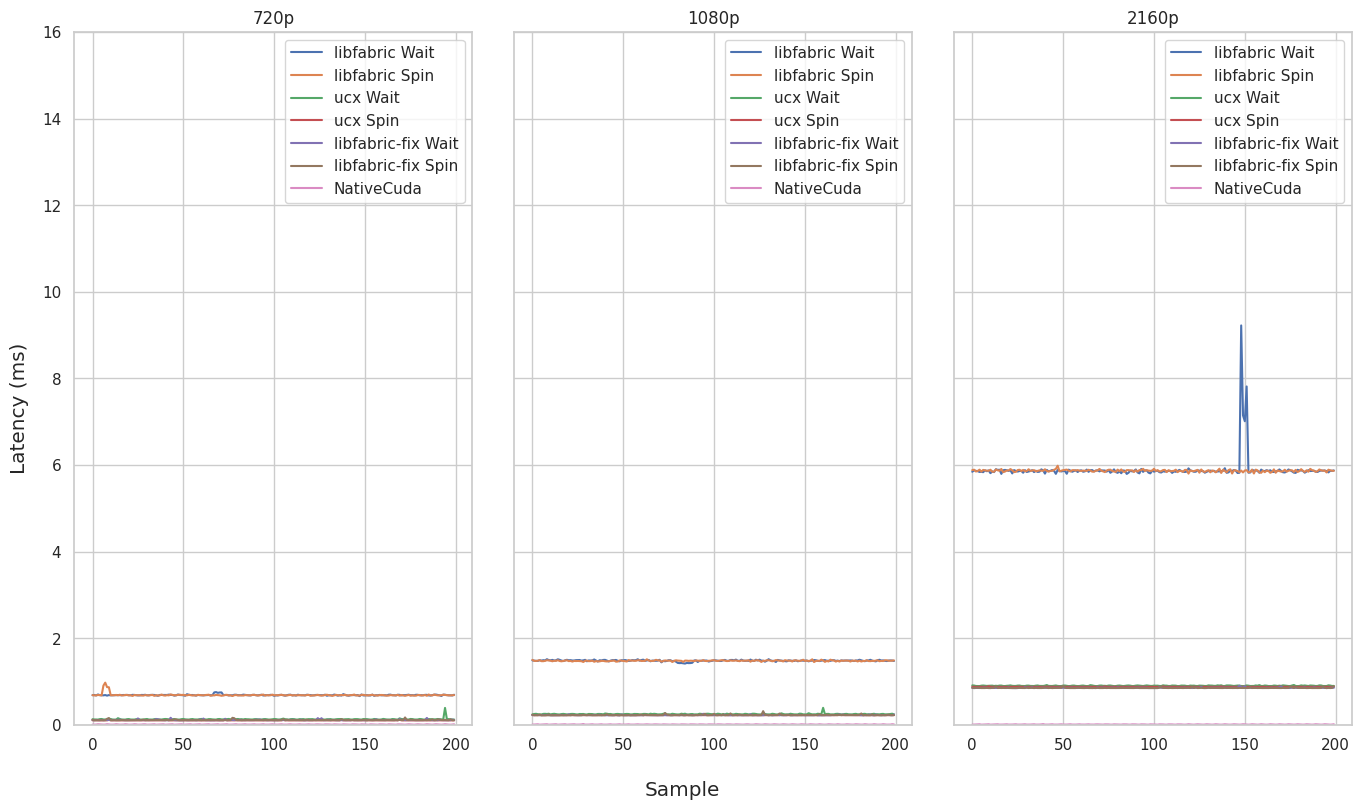

In [27]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")

    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.h2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")

    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric_fix, format, comp, Test.mxl_fabrics, Movement.h2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric-fix {comp.value}")

    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.h2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")

    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

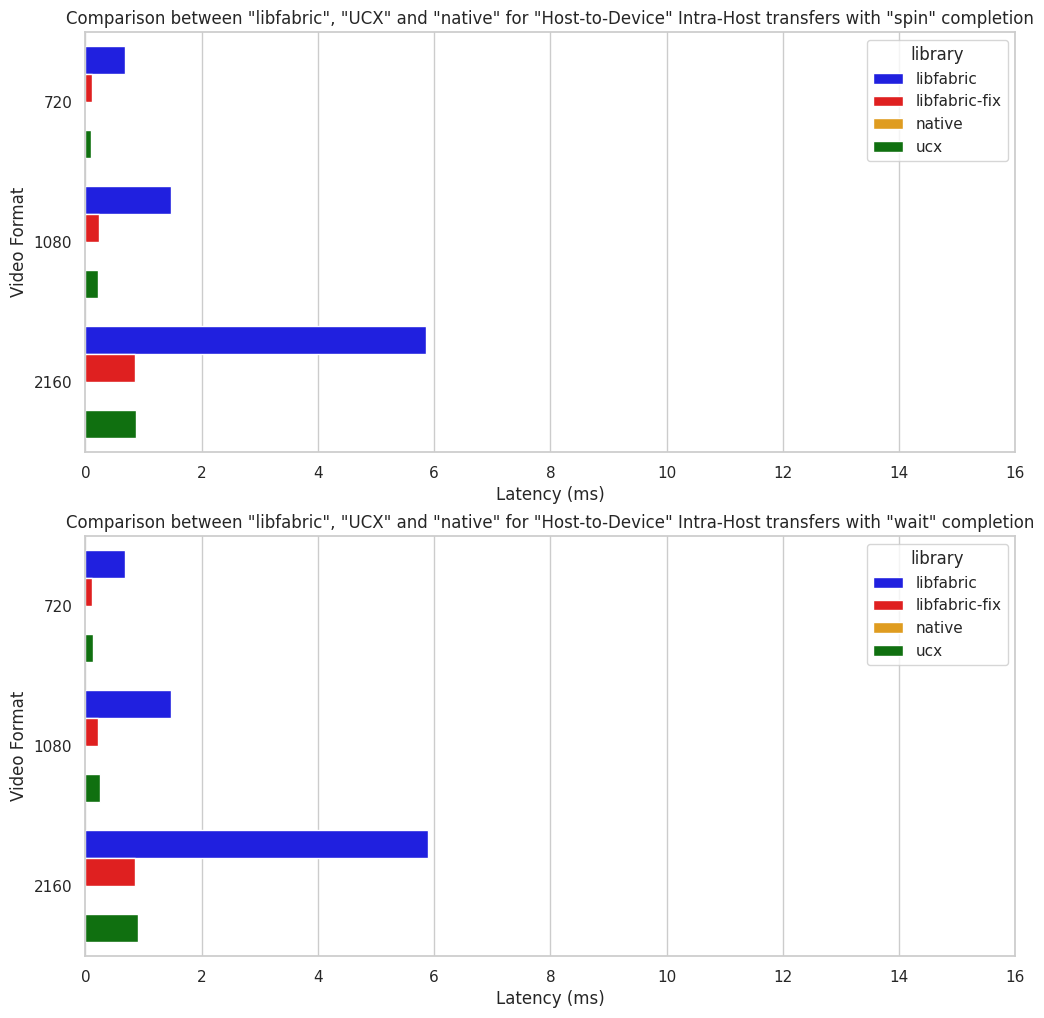

In [28]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"])

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "UCX" and "native" for "Host-to-Device" Intra-Host transfers with "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter((pl.col("completion") == comp.value) | (pl.col("completion") == "")), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [29]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["completion"], descending=True)
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["completion"], descending=True)
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["completion"], descending=True)

In [30]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ native        ┆            ┆ Host2Cuda ┆ 0.0075   ┆ 0.0134  ┆ 0.0032  ┆ 0.0026    │
│ 720    ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 0.6869   ┆ 0.7552  ┆ 0.0119  ┆ 0.0843    │
│ 720    ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.1119   ┆ 0.1626  ┆ 0.0087  ┆ 0.0128    │
│ 720    ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 0.1282   ┆ 0.3898  ┆ 0.0195  ┆ 0.0051    │
│ 720    ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 0.6878   ┆ 0.9736  ┆ 0.0322  ┆ 0.0845    │
│ 720    ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.1109   ┆ 0.1694  ┆ 0.0084  ┆ 0.0112    │
│ 720    ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 0.1036   ┆ 0.1164  ┆ 0.0019  ┆ 0.0142    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72133d5f8a70>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72137d22dc10>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 1280x720 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x721323b3bef0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', val

In [31]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 1920x10880 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ native        ┆            ┆ Host2Cuda ┆ 0.0074   ┆ 0.0177  ┆ 0.0033  ┆ 0.0026    │
│ 1080   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 1.4816   ┆ 1.5148  ┆ 0.0168  ┆ 0.1797    │
│ 1080   ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.2248   ┆ 0.2548  ┆ 0.0045  ┆ 0.0223    │
│ 1080   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 0.2472   ┆ 0.3922  ┆ 0.0121  ┆ 0.0051    │
│ 1080   ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 1.4785   ┆ 1.5131  ┆ 0.0107  ┆ 0.1794    │
│ 1080   ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.2264   ┆ 0.3153  ┆ 0.0098  ┆ 0.023     │
│ 1080   ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 0.2231   ┆ 0.2333  ┆ 0.0017  ┆ 0.0285    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x721322e875f0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72137c185b20>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 1920x10880 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72137d22d610>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', v

In [32]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Host-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Inter-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (7, 8)
┌────────┬───────────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library       ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---           ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum          ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ native        ┆            ┆ Host2Cuda ┆ 0.0074   ┆ 0.0163  ┆ 0.0032  ┆ 0.0025    │
│ 2160   ┆ libfabric     ┆ Wait       ┆ Host2Cuda ┆ 5.8963   ┆ 9.2231  ┆ 0.3004  ┆ 0.7089    │
│ 2160   ┆ libfabric-fix ┆ Wait       ┆ Host2Cuda ┆ 0.8542   ┆ 0.902   ┆ 0.0062  ┆ 0.0555    │
│ 2160   ┆ ucx           ┆ Wait       ┆ Host2Cuda ┆ 0.9016   ┆ 0.9196  ┆ 0.0055  ┆ 0.0049    │
│ 2160   ┆ libfabric     ┆ Spin       ┆ Host2Cuda ┆ 5.8673   ┆ 5.9836  ┆ 0.0238  ┆ 0.7054    │
│ 2160   ┆ libfabric-fix ┆ Spin       ┆ Host2Cuda ┆ 0.8525   ┆ 0.8958  ┆ 0.0067  ┆ 0.0569    │
│ 2160   ┆ ucx           ┆ Spin       ┆ Host2Cuda ┆ 0.8784   ┆ 0.8906  ┆ 0.0017  ┆ 0.1072    │
└────────┴───────────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72136d03aa80>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72133d5ef7a0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Host-to-Device transfer latency comparison for 3840x2160 frames', subtitle='Inter-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72137c11acc0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', va

## Device to Host Intra-Host

In [33]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2h], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/d2h-intrahost", diff_loader, **config)

### Comparison libfabric vs native cuda vs UCX for Device-to-Host transfers

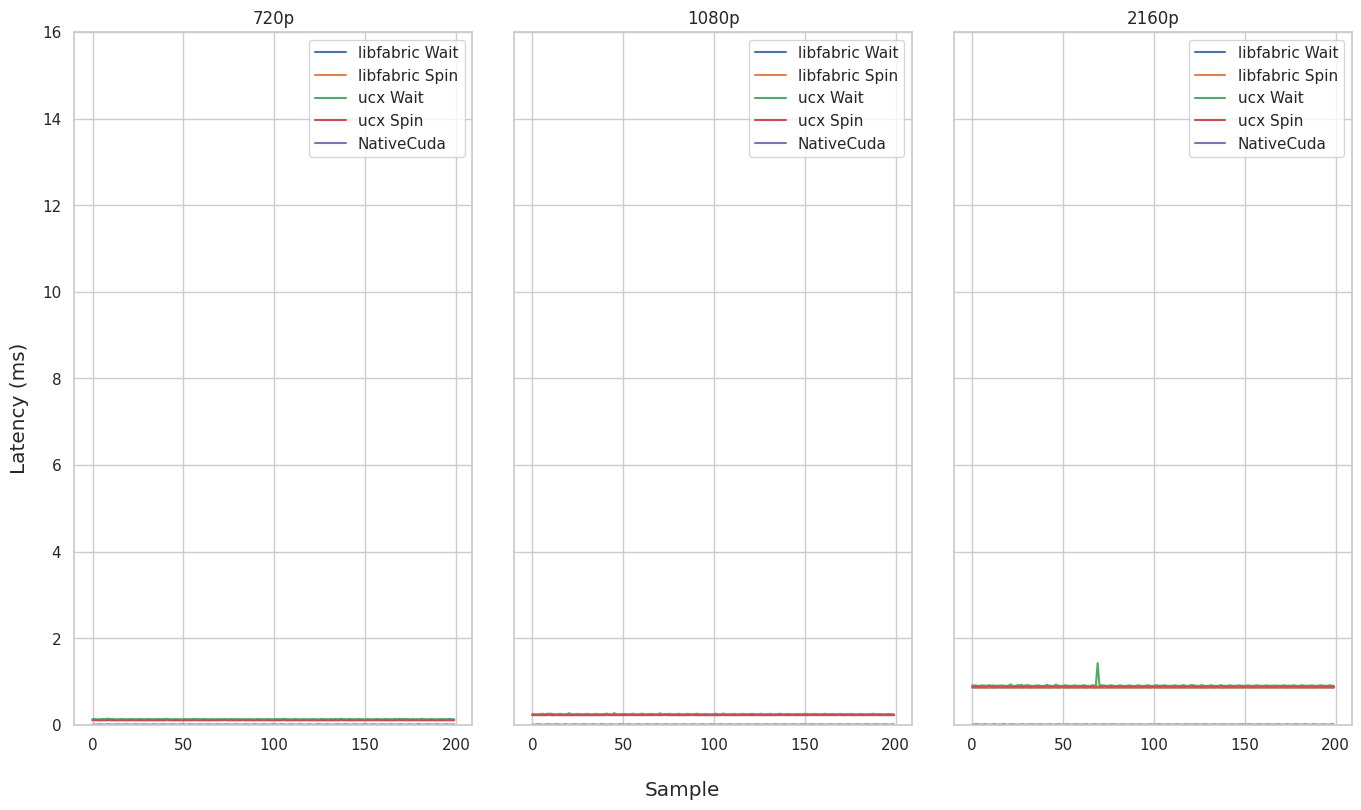

In [34]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2h, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2h, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2h, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

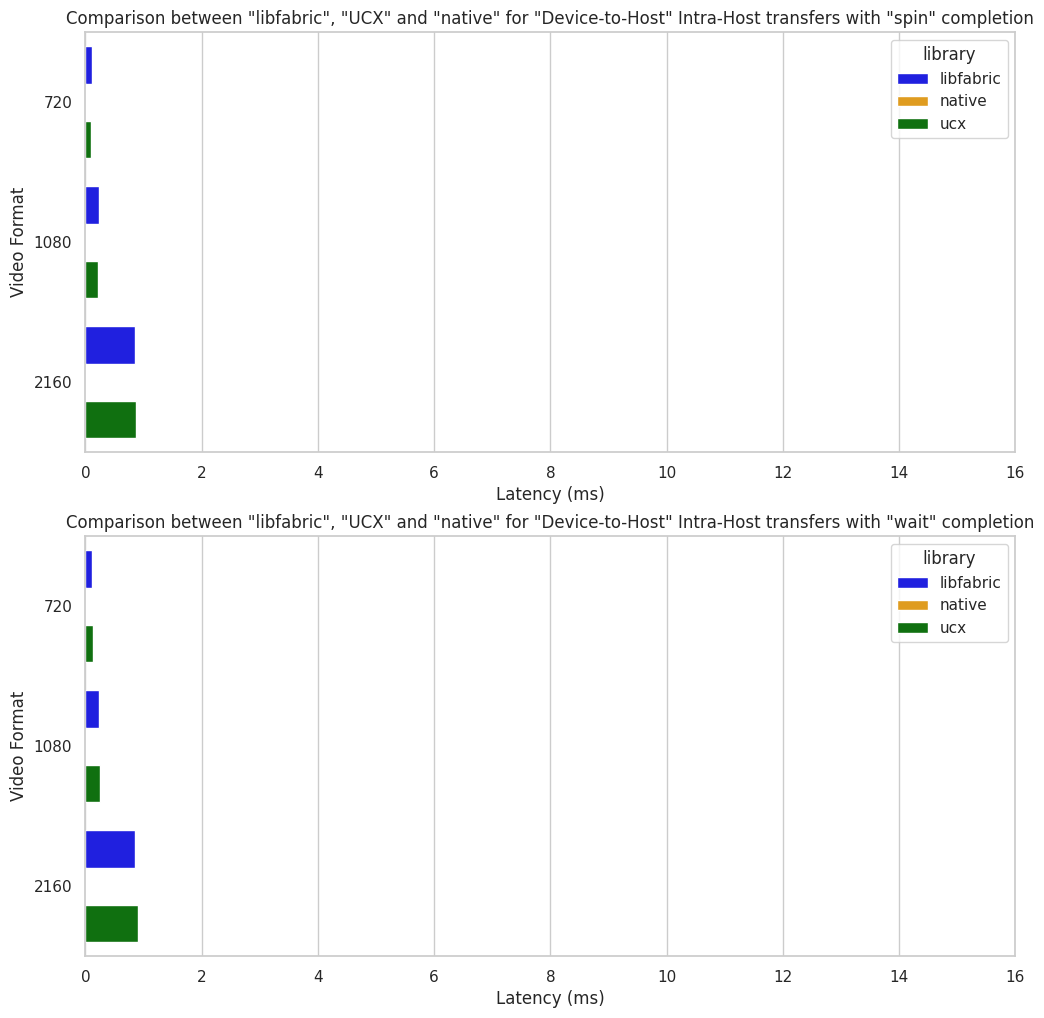

In [35]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"]).sort(pl.col("library"))
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "UCX" and "native" for "Device-to-Host" Intra-Host transfers with "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter((pl.col("completion") == comp.value) | (pl.col("completion") == "")), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [36]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["completion"], descending=True)
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["completion"], descending=True)
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["completion"], descending=True)

In [37]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 1280x720 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ native    ┆            ┆ Cuda2Host ┆ 0.0073   ┆ 0.014   ┆ 0.0032  ┆ 0.0024    │
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.1162   ┆ 0.1354  ┆ 0.004   ┆ 0.0155    │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 0.1271   ┆ 0.1446  ┆ 0.0059  ┆ 0.0051    │
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.1141   ┆ 0.1332  ┆ 0.0042  ┆ 0.0155    │
│ 720    ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 0.1038   ┆ 0.1147  ┆ 0.0018  ┆ 0.0141    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72137c107a70>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72136c961ee0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 1280x720 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72136d019580>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px'

In [38]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 1920x1080 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ native    ┆            ┆ Cuda2Host ┆ 0.0071   ┆ 0.0132  ┆ 0.0032  ┆ 0.0026    │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.2312   ┆ 0.239   ┆ 0.0034  ┆ 0.0293    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 0.2463   ┆ 0.2695  ┆ 0.0058  ┆ 0.005     │
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.229    ┆ 0.2387  ┆ 0.0036  ┆ 0.0292    │
│ 1080   ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 0.2235   ┆ 0.2348  ┆ 0.0017  ┆ 0.0284    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72137c1068d0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72133fba0320>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 1920x1080 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72136c92cb00>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px

In [39]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Host transfer latency comparison for 3840x2160 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ native    ┆            ┆ Cuda2Host ┆ 0.0074   ┆ 0.0154  ┆ 0.003   ┆ 0.0025    │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Host ┆ 0.8609   ┆ 0.8706  ┆ 0.0037  ┆ 0.105     │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Host ┆ 0.9071   ┆ 1.4253  ┆ 0.0374  ┆ 0.0055    │
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Host ┆ 0.8584   ┆ 0.8666  ┆ 0.0036  ┆ 0.1048    │
│ 2160   ┆ ucx       ┆ Spin       ┆ Cuda2Host ┆ 0.8792   ┆ 0.8906  ┆ 0.0016  ┆ 0.1073    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x72133d55ecc0>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x72133fba1130>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Host transfer latency comparison for 3840x2160 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x72133dd99760>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px

## Device to Device Intra-host Inter-GPU

In [40]:
config = {"libraries": [Library.libfabric], "movements": [Movement.d2d], "transports":[Transport.shm], "tx_modes": [TransferMode.oneway], "completions":[Completion.wait,Completion.spin], "tests": [Test.mxl_fabrics, Test.native_cuda, Test.ucx]}
data, perf, _ = load_data(f"{data_dir}/d2d-intrahost", diff_loader, **config)

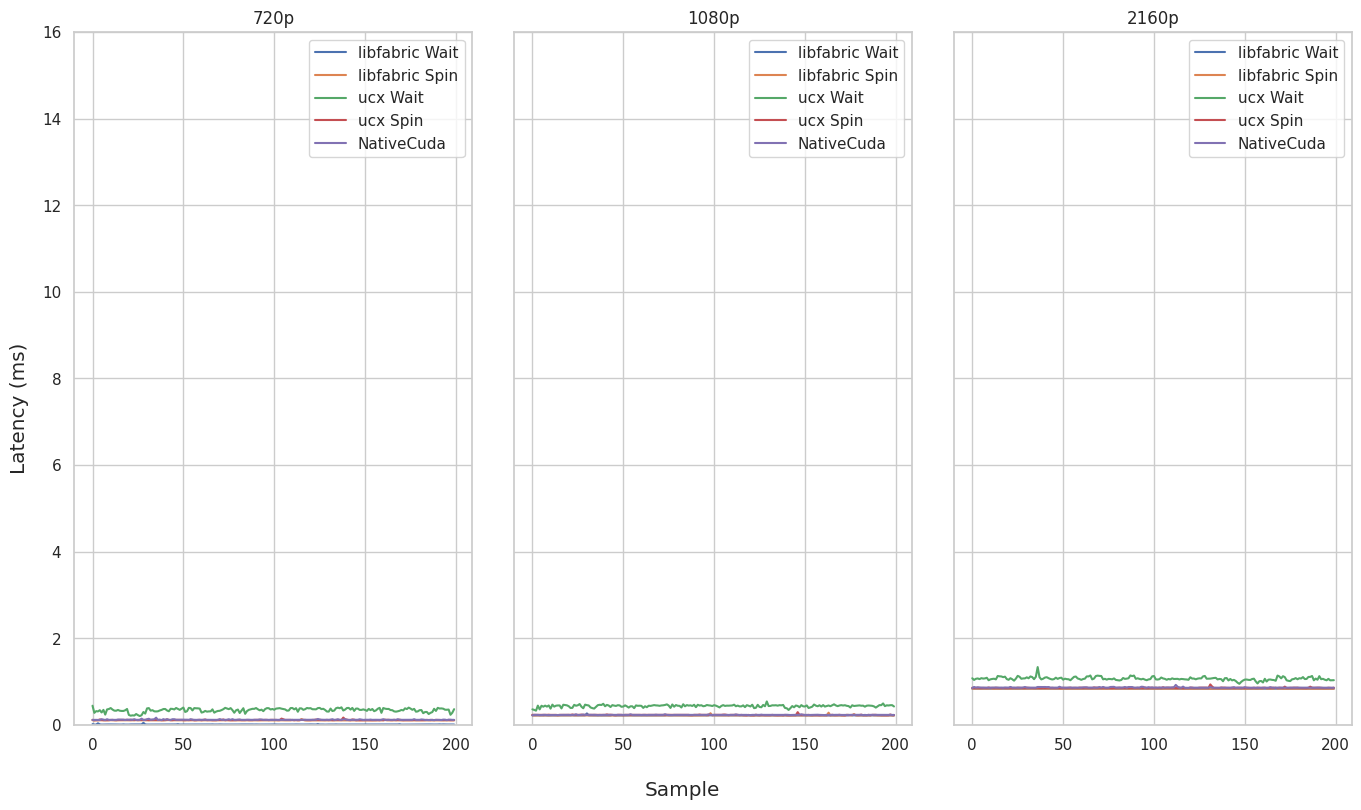

In [41]:
fig, axs = plt.subplots(nrows=1, ncols=len(Format), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(Format):
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.libfabric, format, comp, Test.mxl_fabrics, Movement.d2d, Transport.shm, TransferMode.oneway)]/1e6, label=f"libfabric {comp.value}")
    for comp in config["completions"]:
        axs[i].plot(data[TestConfiguration(Library.ucx, format, comp, Test.ucx, Movement.d2d, Transport.none, TransferMode.oneway)]/1e6, label=f"ucx {comp.value}")
    axs[i].plot(data[TestConfiguration(Library.native, format, Completion.none, Test.native_cuda, Movement.d2d, Transport.none, TransferMode.none)]/1e6, label=f"{Test.native_cuda.value}")
    axs[i].set_title(f"{format.value}p")
    axs[i].set_ylim(0, 16)
    axs[i].legend()

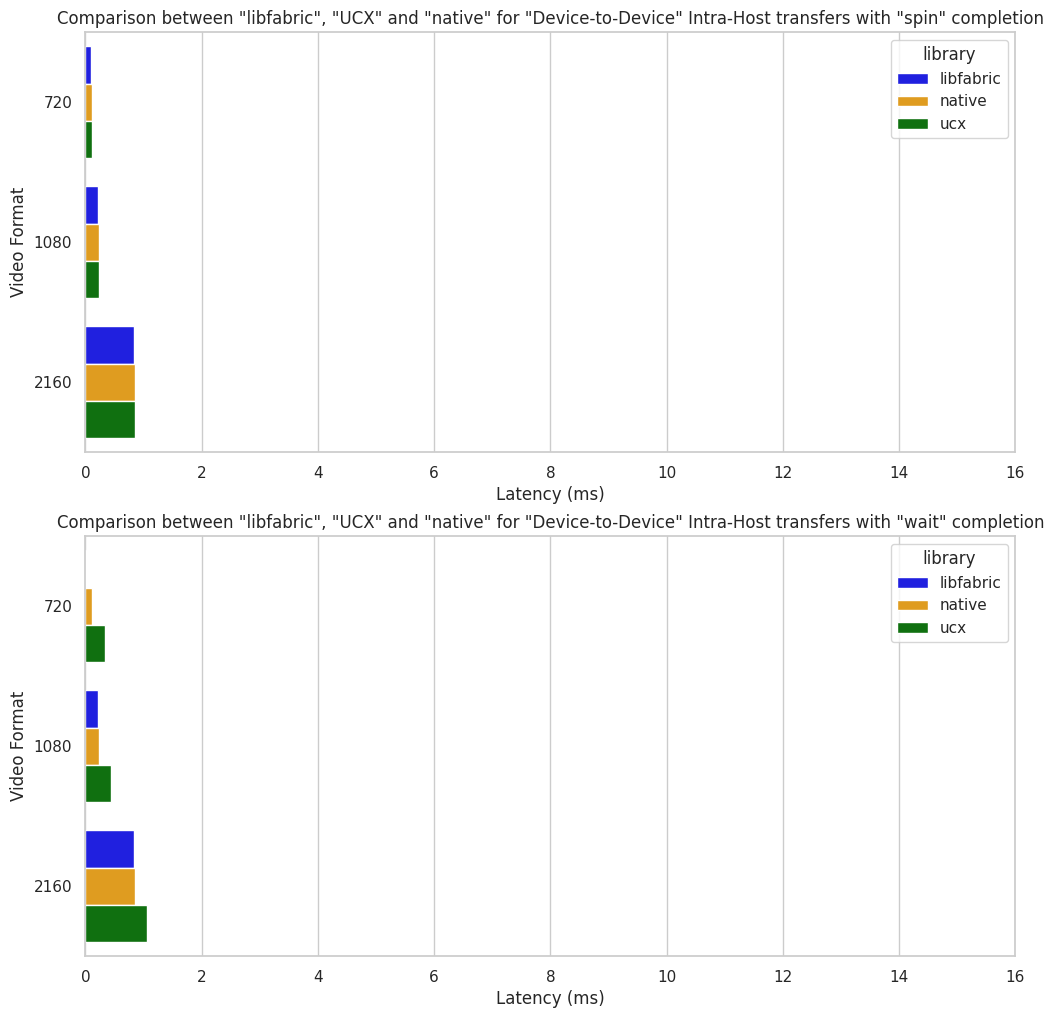

In [47]:
data_df = make_table(data, perf, columns=["format", "library", "completion", "movement"]).sort(pl.col("library"))
# only keep used movements
data_df = data_df.with_columns(
    pl.col('library').cast(pl.Categorical)
)

comps = [Completion.spin, Completion.wait]
fig, axs = plt.subplots(nrows=len(comps), ncols=1, figsize=(12, 12))
for i, comp in enumerate(comps):
    axs[i].set_title(f'Comparison between "libfabric", "UCX" and "native" for "Device-to-Device" Intra-Host transfers with "{comp.name}" completion')
    axs[i].set_xlabel("Latency (ms)")
    axs[i].set_ylabel("Video Format")
    axs[i].set_xlim(0,16)
    sns.barplot(data=data_df.filter((pl.col("completion") == comp.value) | (pl.col("completion") == "")), x='lat_mean', y="format", hue='library', orient='h', ax=axs[i], palette=color_map);

In [43]:
data_columns = ["format", "library", "completion", "movement"]
data_df = make_table(data, perf,columns=data_columns)
data_df_720 = data_df.filter(pl.col("format") == "720").sort(["completion"], descending=True)
data_df_1080 = data_df.filter(pl.col("format") == "1080").sort(["completion"], descending=True)
data_df_2160 = data_df.filter(pl.col("format") == "2160").sort(["completion"], descending=True)

In [44]:
table = GT(data_df_720)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1280x720 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format", "movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 720    ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.1174   ┆ 0.1652  ┆ 0.0065  ┆ 0.0312    │
│ 720    ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.0071   ┆ 0.0463  ┆ 0.0037  ┆ 0.0061    │
│ 720    ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 0.3404   ┆ 0.4406  ┆ 0.0433  ┆ 0.0216    │
│ 720    ┆ libfabric ┆ Spin       ┆ Cuda2Cuda ┆ 0.1033   ┆ 0.1317  ┆ 0.003   ┆ 0.02      │
│ 720    ┆ ucx       ┆ Spin       ┆ Cuda2Cuda ┆ 0.1118   ┆ 0.1676  ┆ 0.0061  ┆ 0.0182    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7725b1d3ce90>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b805aa50>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1280x720 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7725b2ca4650>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='p

In [45]:
table = GT(data_df_1080)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 1920x1080 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 1080   ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.2289   ┆ 0.2438  ┆ 0.003   ┆ 0.0302    │
│ 1080   ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.218    ┆ 0.2631  ┆ 0.0035  ┆ 0.0317    │
│ 1080   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 0.4343   ┆ 0.5395  ┆ 0.0277  ┆ 0.0118    │
│ 1080   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda ┆ 0.2181   ┆ 0.2799  ┆ 0.0063  ┆ 0.0317    │
│ 1080   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda ┆ 0.2276   ┆ 0.2919  ┆ 0.0062  ┆ 0.0323    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7725b358ca90>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b2dfc490>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 1920x1080 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7725b3524250>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='

In [46]:
table = GT(data_df_2160)

table
(
    table
    .tab_header(
        title="Device-to-Device transfer latency comparison for 3840x2160 frames",
        subtitle="Intra-Host",
    )
    .tab_spanner(
        label="Configuration",
        columns=data_columns
    )
    .tab_spanner(
        label="CPU",
        columns=["cpu_usage"]
    )
    .tab_spanner(
        label="Latency (ms)",
        columns=["lat_mean", "lat_max", "lat_std"]
    )
    .cols_label(lat_mean="mean", lat_max="max", lat_std="std", cpu_usage="usage")
    .cols_hide(columns=["format","movement"])
)

GT(_tbl_data=shape: (5, 8)
┌────────┬───────────┬────────────┬───────────┬──────────┬─────────┬─────────┬───────────┐
│ format ┆ library   ┆ completion ┆ movement  ┆ lat_mean ┆ lat_max ┆ lat_std ┆ cpu_usage │
│ ---    ┆ ---       ┆ ---        ┆ ---       ┆ ---      ┆ ---     ┆ ---     ┆ ---       │
│ enum   ┆ enum      ┆ enum       ┆ enum      ┆ f64      ┆ f64     ┆ f64     ┆ f64       │
╞════════╪═══════════╪════════════╪═══════════╪══════════╪═════════╪═════════╪═══════════╡
│ 2160   ┆ native    ┆            ┆ Cuda2Cuda ┆ 0.8605   ┆ 0.9218  ┆ 0.0074  ┆ 0.1058    │
│ 2160   ┆ libfabric ┆ Wait       ┆ Cuda2Cuda ┆ 0.8347   ┆ 0.8371  ┆ 0.0007  ┆ 0.1031    │
│ 2160   ┆ ucx       ┆ Wait       ┆ Cuda2Cuda ┆ 1.0654   ┆ 1.3338  ┆ 0.0395  ┆ 0.0148    │
│ 2160   ┆ libfabric ┆ Spin       ┆ Cuda2Cuda ┆ 0.8352   ┆ 0.8573  ┆ 0.0024  ┆ 0.1044    │
│ 2160   ┆ ucx       ┆ Spin       ┆ Cuda2Cuda ┆ 0.854    ┆ 0.9324  ┆ 0.0075  ┆ 0.1067    │
└────────┴───────────┴────────────┴───────────┴──────────┴─────────┴─────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x7725bab4e690>, _boxhead=Boxhead([ColInfo(var='format', type=<ColInfoTypeEnum.hidden: 4>, column_label='format', column_align='center', column_width=None), ColInfo(var='library', type=<ColInfoTypeEnum.default: 1>, column_label='library', column_align='center', column_width=None), ColInfo(var='completion', type=<ColInfoTypeEnum.default: 1>, column_label='completion', column_align='center', column_width=None), ColInfo(var='movement', type=<ColInfoTypeEnum.hidden: 4>, column_label='movement', column_align='center', column_width=None), ColInfo(var='lat_mean', type=<ColInfoTypeEnum.default: 1>, column_label='mean', column_align='right', column_width=None), ColInfo(var='lat_max', type=<ColInfoTypeEnum.default: 1>, column_label='max', column_align='right', column_width=None), ColInfo(var='lat_std', type=<ColInfoTypeEnum.default: 1>, column_label='std', column_align='right', column_width=None), ColInfo(var='cpu_usage', type=<ColInfoTypeEnum.default: 1>, column_label='usage', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7725b35b23d0>, _spanners=Spanners([SpannerInfo(spanner_id='Configuration', spanner_level=0, spanner_label='Configuration', spanner_units=None, spanner_pattern=None, vars=['format', 'library', 'completion', 'movement'], built=None), SpannerInfo(spanner_id='CPU', spanner_level=0, spanner_label='CPU', spanner_units=None, spanner_pattern=None, vars=['cpu_usage'], built=None), SpannerInfo(spanner_id='Latency (ms)', spanner_level=0, spanner_label='Latency (ms)', spanner_units=None, spanner_pattern=None, vars=['lat_mean', 'lat_max', 'lat_std'], built=None)]), _heading=Heading(title='Device-to-Device transfer latency comparison for 3840x2160 frames', subtitle='Intra-Host', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7725b3598650>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='